In [1]:
source("config.r")

In [2]:
library(ggplot2)
library(caret)
library(corrplot)
library(car)
library(dplyr)
library(tidyr)
options(warn = -1)

Loading required package: lattice

corrplot 0.95 loaded

Loading required package: carData


Attaching package: ‘dplyr’


The following object is masked from ‘package:car’:

    recode


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
df.train <- read.csv(TRAINING_DATA_PATH)
str(df.train)

'data.frame':	440833 obs. of  12 variables:
 $ CustomerID       : int  2 3 4 5 6 8 9 10 11 12 ...
 $ Age              : int  30 65 55 58 23 51 58 55 39 64 ...
 $ Gender           : chr  "Female" "Female" "Female" "Male" ...
 $ Tenure           : int  39 49 14 38 32 33 49 37 12 3 ...
 $ Usage.Frequency  : int  14 1 4 21 20 25 12 8 5 25 ...
 $ Support.Calls    : int  5 10 6 7 5 9 3 4 7 2 ...
 $ Payment.Delay    : int  18 8 18 7 8 26 16 15 4 11 ...
 $ Subscription.Type: chr  "Standard" "Basic" "Basic" "Standard" ...
 $ Contract.Length  : chr  "Annual" "Monthly" "Quarterly" "Monthly" ...
 $ Total.Spend      : num  932 557 185 396 617 129 821 445 969 415 ...
 $ Last.Interaction : int  17 6 3 29 20 8 24 30 13 29 ...
 $ Churn            : int  1 1 1 1 1 1 1 1 1 1 ...


In [4]:
df.train$CustomerID <- NULL
df.train$Gender <- as.factor(df.train$Gender)
df.train$Subscription.Type <- as.factor(df.train$Subscription.Type)
df.train$Contract.Length <- as.factor(df.train$Contract.Length)
df.train$Churn <- as.factor(df.train$Churn)
df.train$Churn.num <- as.numeric(as.character(df.train$Churn))

In [5]:
summary(df.train)

      Age           Gender           Tenure      Usage.Frequency
 Min.   :18.00         :     1   Min.   : 1.00   Min.   : 1.00  
 1st Qu.:29.00   Female:190580   1st Qu.:16.00   1st Qu.: 9.00  
 Median :39.00   Male  :250252   Median :32.00   Median :16.00  
 Mean   :39.37                   Mean   :31.26   Mean   :15.81  
 3rd Qu.:48.00                   3rd Qu.:46.00   3rd Qu.:23.00  
 Max.   :65.00                   Max.   :60.00   Max.   :30.00  
 NA's   :1                       NA's   :1       NA's   :1      
 Support.Calls    Payment.Delay   Subscription.Type  Contract.Length  
 Min.   : 0.000   Min.   : 0.00           :     1            :     1  
 1st Qu.: 1.000   1st Qu.: 6.00   Basic   :143026   Annual   :177198  
 Median : 3.000   Median :12.00   Premium :148678   Monthly  : 87104  
 Mean   : 3.604   Mean   :12.97   Standard:149128   Quarterly:176530  
 3rd Qu.: 6.000   3rd Qu.:19.00                                       
 Max.   :10.000   Max.   :30.00                       

In [6]:
missing.idx <- which(!complete.cases(df.train))
missing.rows <- df.train[missing.idx, ]
missing.rows$row_number <- missing.idx

print(missing.rows, row.names = FALSE)

 Age Gender Tenure Usage.Frequency Support.Calls Payment.Delay
  NA            NA              NA            NA            NA
 Subscription.Type Contract.Length Total.Spend Last.Interaction Churn Churn.num
                                            NA               NA  <NA>        NA
 row_number
     199296


In [7]:
df.train <- df.train[complete.cases(df.train), ]
df.train <- droplevels(df.train)
summary(df.train)

      Age           Gender           Tenure      Usage.Frequency
 Min.   :18.00   Female:190580   Min.   : 1.00   Min.   : 1.00  
 1st Qu.:29.00   Male  :250252   1st Qu.:16.00   1st Qu.: 9.00  
 Median :39.00                   Median :32.00   Median :16.00  
 Mean   :39.37                   Mean   :31.26   Mean   :15.81  
 3rd Qu.:48.00                   3rd Qu.:46.00   3rd Qu.:23.00  
 Max.   :65.00                   Max.   :60.00   Max.   :30.00  
 Support.Calls    Payment.Delay   Subscription.Type  Contract.Length  
 Min.   : 0.000   Min.   : 0.00   Basic   :143026   Annual   :177198  
 1st Qu.: 1.000   1st Qu.: 6.00   Premium :148678   Monthly  : 87104  
 Median : 3.000   Median :12.00   Standard:149128   Quarterly:176530  
 Mean   : 3.604   Mean   :12.97                                       
 3rd Qu.: 6.000   3rd Qu.:19.00                                       
 Max.   :10.000   Max.   :30.00                                       
  Total.Spend     Last.Interaction Churn        

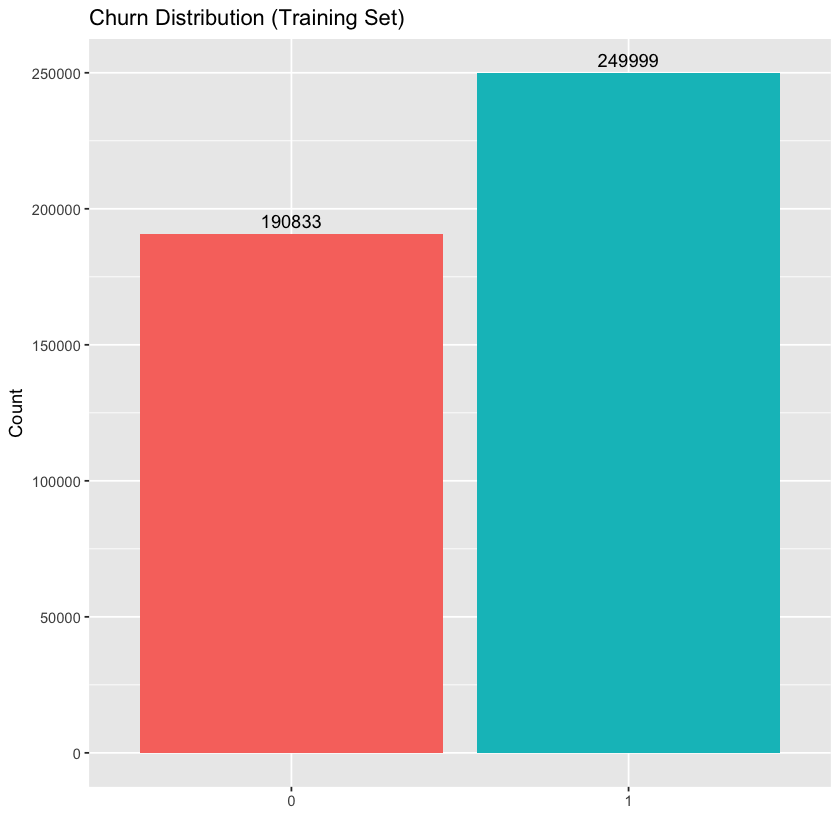

In [8]:
ggplot(df.train, aes(x = Churn, fill = Churn)) +
    geom_bar() +
    geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
    labs(title = "Churn Distribution (Training Set)",
         x = "", y = "Count") +
    theme(legend.position = "none")

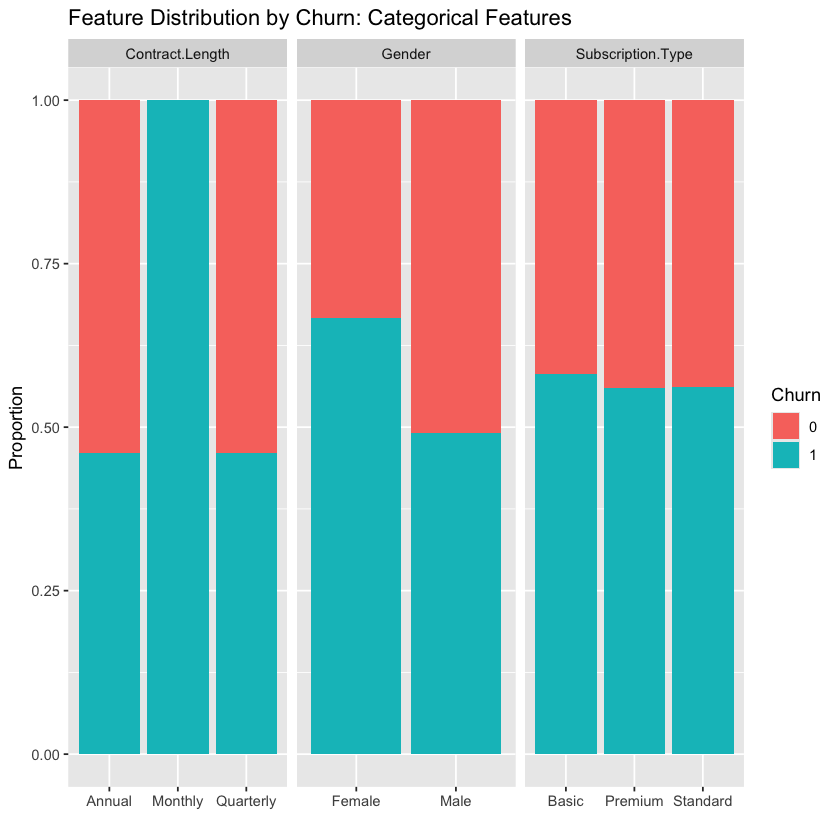

In [9]:
categorical.features <- c("Gender", "Subscription.Type", "Contract.Length")

df.cat.long <- pivot_longer(data = df.train[, c("Churn", categorical.features)],
                            cols = -Churn,
                            names_to = "feature",
                            values_to = "value")

ggplot(df.cat.long, aes(x = value, fill = Churn)) + 
    geom_bar(position = "fill")+
    facet_wrap(~feature, scales = "free_x")+
    labs(title = "Feature Distribution by Churn: Categorical Features",
         x = "", y = "Proportion")

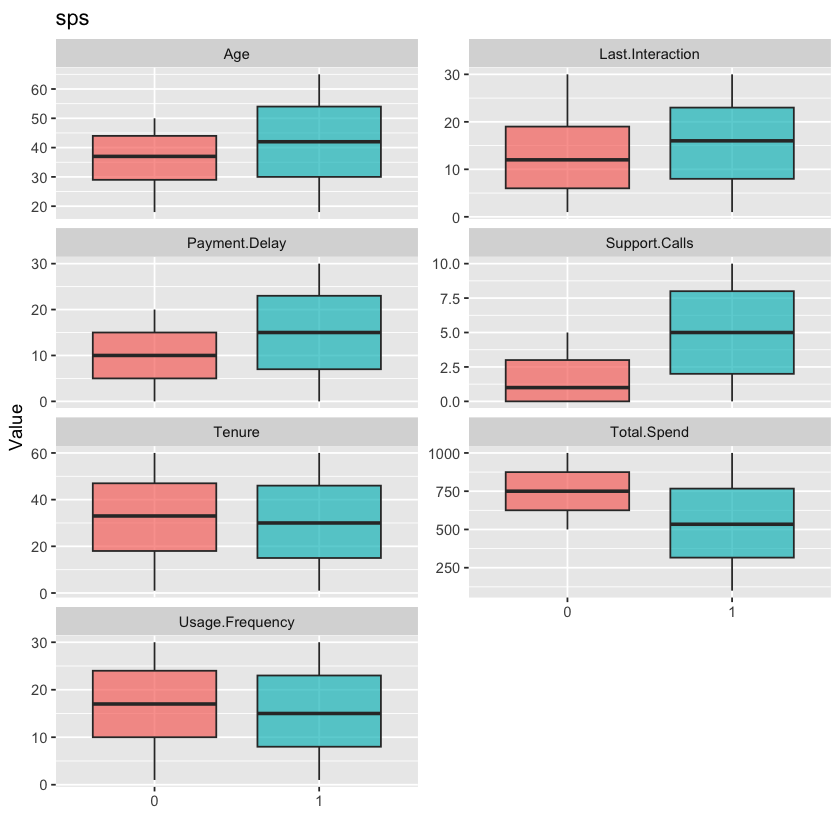

In [10]:
numeric.features <- c("Age", "Tenure", "Usage.Frequency", "Support.Calls", 
                  "Payment.Delay", "Total.Spend", "Last.Interaction")

df.long <- pivot_longer(data = df.train[, c("Churn", numeric.features)],
                        cols = -Churn,
                        names_to = "feature",
                        values_to = "value")

ggplot(df.long, aes(x = Churn, y = value, fill = Churn)) +
    geom_boxplot(outlier.size = 0.5, alpha = 0.7) + 
    facet_wrap(~ feature, scales = "free_y", ncol = 2) + 
    labs(title = "sps ", 
         x = "", y = "Value") + 
    theme(legend.position = "none")

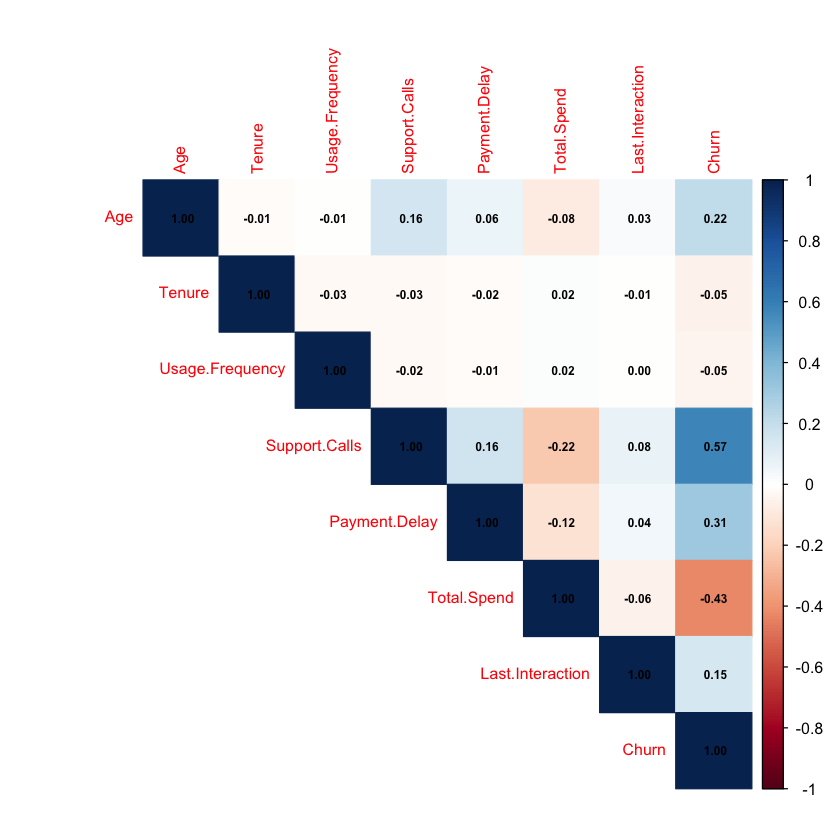

In [11]:
cor.data <- df.train[, numeric.features]
cor.data$Churn <- df.train$Churn.num

corrplot(cor(cor.data, use = "complete.obs"),
    method = "color",
    type = "upper",
    tl.cex = 0.8, 
    addCoef.col = "black",
    number.cex = 0.6)

In [12]:
lm.proxy <- lm(Churn.num ~ . - Churn, data = df.train)
vif.result <- vif(lm.proxy)

vif.data <- data.frame(
    Feature = rownames(vif.result),
    VIF = round(vif.result[, 1], 3)
)

print(vif.data, row.names = FALSE)

           Feature   VIF
               Age 1.032
            Gender 1.036
            Tenure 1.003
   Usage.Frequency 1.002
     Support.Calls 1.138
     Payment.Delay 1.045
 Subscription.Type 1.001
   Contract.Length 1.082
       Total.Spend 1.080
  Last.Interaction 1.032


In [13]:
step.result <- stats::step(lm.proxy, direction = "backward")
summary(step.result)

Start:  AIC=-980818.1
Churn.num ~ (Age + Gender + Tenure + Usage.Frequency + Support.Calls + 
    Payment.Delay + Subscription.Type + Contract.Length + Total.Spend + 
    Last.Interaction + Churn) - Churn

                    Df Sum of Sq   RSS     AIC
<none>                           47640 -980818
- Subscription.Type  2      12.7 47653 -980704
- Usage.Frequency    1      63.5 47704 -980233
- Tenure             1      74.3 47715 -980133
- Last.Interaction   1     909.1 48549 -972487
- Age                1     926.4 48567 -972330
- Gender             1    1163.8 48804 -970181
- Payment.Delay      1    2945.0 50585 -954378
- Total.Spend        1    6564.1 54204 -923916
- Contract.Length    2    6728.1 54368 -922587
- Support.Calls      1   15149.6 62790 -859100



Call:
lm(formula = Churn.num ~ (Age + Gender + Tenure + Usage.Frequency + 
    Support.Calls + Payment.Delay + Subscription.Type + Contract.Length + 
    Total.Spend + Last.Interaction + Churn) - Churn, data = df.train)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.89981 -0.25496 -0.06571  0.24767  1.11785 

Coefficients:
                            Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                3.614e-01  3.050e-03  118.499   <2e-16 ***
Age                        3.743e-03  4.043e-05   92.586   <2e-16 ***
GenderMale                -1.056e-01  1.017e-03 -103.771   <2e-16 ***
Tenure                    -7.536e-04  2.873e-05  -26.225   <2e-16 ***
Usage.Frequency           -1.399e-03  5.771e-05  -24.235   <2e-16 ***
Support.Calls              6.440e-02  1.720e-04  374.406   <2e-16 ***
Payment.Delay              1.012e-02  6.128e-05  165.076   <2e-16 ***
Subscription.TypePremium  -1.169e-02  1.218e-03   -9.598   <2e-16 ***
Subscription.TypeStandard -1.1

In [14]:
set.seed(42)
ctrl <- trainControl(method = "cv", number = 5)

cv.model <- train(Churn ~ Age + Gender + Tenure + Usage.Frequency + 
                    Support.Calls + Payment.Delay + Subscription.Type + Contract.Length + 
                    Total.Spend + Last.Interaction,
                data = df.train,
                method = "glm",
                family = "binomial",
                trControl = ctrl, 
                maxit = 300,
                trace = FALSE)
cv.model

Generalized Linear Model 

440832 samples
    10 predictor
     2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 352665, 352666, 352665, 352666, 352666 
Resampling results:

  Accuracy  Kappa    
  0.895332  0.7881647


In [15]:
df.test <- read.csv(TESTING_DATA_PATH)
df.test$Churn <- as.factor(df.test$Churn)
missing.rows <- df.test[!complete.cases(df.test), ]
print(missing.rows, row.names = FALSE)

 [1] CustomerID        Age               Gender            Tenure           
 [5] Usage.Frequency   Support.Calls     Payment.Delay     Subscription.Type
 [9] Contract.Length   Total.Spend       Last.Interaction  Churn            
<0 rows> (or 0-length row.names)


In [16]:
df.test$CustomerID <- NULL

df.test$Gender <- as.factor(df.test$Gender)
df.test$Subscription.Type <- as.factor(df.test$Subscription.Type)
df.test$Contract.Length <- as.factor(df.test$Contract.Length)
df.test$Churn <- as.factor(df.test$Churn)

In [17]:
str(df.test)
summary(df.test)

'data.frame':	64374 obs. of  11 variables:
 $ Age              : int  22 41 47 35 53 30 47 54 36 65 ...
 $ Gender           : Factor w/ 2 levels "Female","Male": 1 1 2 2 1 2 1 1 2 2 ...
 $ Tenure           : int  25 28 27 9 58 41 37 36 20 8 ...
 $ Usage.Frequency  : int  14 28 10 12 24 14 15 11 5 4 ...
 $ Support.Calls    : int  4 7 2 5 9 10 9 0 10 2 ...
 $ Payment.Delay    : int  27 13 29 17 2 10 28 18 8 23 ...
 $ Subscription.Type: Factor w/ 3 levels "Basic","Premium",..: 1 3 2 2 3 2 1 3 1 1 ...
 $ Contract.Length  : Factor w/ 3 levels "Annual","Monthly",..: 2 2 1 3 1 2 3 2 2 1 ...
 $ Total.Spend      : int  598 584 757 232 533 500 574 323 687 995 ...
 $ Last.Interaction : int  9 20 21 18 18 29 14 16 8 10 ...
 $ Churn            : Factor w/ 2 levels "0","1": 2 1 1 1 1 1 2 1 1 1 ...


      Age           Gender          Tenure      Usage.Frequency
 Min.   :18.00   Female:34353   Min.   : 1.00   Min.   : 1.00  
 1st Qu.:30.00   Male  :30021   1st Qu.:18.00   1st Qu.: 7.00  
 Median :42.00                  Median :33.00   Median :15.00  
 Mean   :41.97                  Mean   :31.99   Mean   :15.08  
 3rd Qu.:54.00                  3rd Qu.:47.00   3rd Qu.:23.00  
 Max.   :65.00                  Max.   :60.00   Max.   :30.00  
 Support.Calls    Payment.Delay   Subscription.Type  Contract.Length 
 Min.   : 0.000   Min.   : 0.00   Basic   :21451    Annual   :21410  
 1st Qu.: 3.000   1st Qu.:10.00   Premium :21421    Monthly  :22130  
 Median : 6.000   Median :19.00   Standard:21502    Quarterly:20834  
 Mean   : 5.401   Mean   :17.13                                      
 3rd Qu.: 8.000   3rd Qu.:25.00                                      
 Max.   :10.000   Max.   :30.00                                      
  Total.Spend   Last.Interaction Churn    
 Min.   : 100   Min

In [18]:
pred <- predict(cv.model, newdata = df.test, type = "raw")
cm <- confusionMatrix(pred, df.test$Churn)
cm 

Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0  6566   287
         1 27315 30206
                                          
               Accuracy : 0.5712          
                 95% CI : (0.5674, 0.5751)
    No Information Rate : 0.5263          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.1766          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.1938          
            Specificity : 0.9906          
         Pos Pred Value : 0.9581          
         Neg Pred Value : 0.5251          
             Prevalence : 0.5263          
         Detection Rate : 0.1020          
   Detection Prevalence : 0.1065          
      Balanced Accuracy : 0.5922          
                                          
       'Positive' Class : 0               
                  

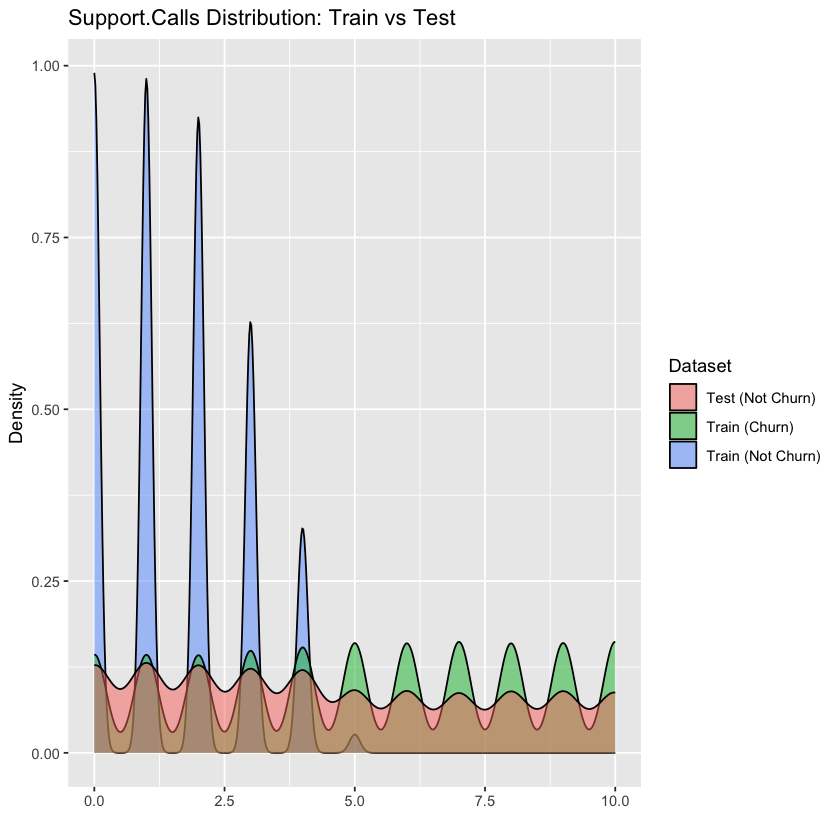

In [19]:
ggplot() +
    geom_density(data = df.train[df.train$Churn == 0, ], 
                 aes(x = Support.Calls, fill = "Train (Not Churn)"), alpha = 0.5) +
    geom_density(data = df.train[df.train$Churn == 1, ], 
                 aes(x = Support.Calls, fill = "Train (Churn)"), alpha = 0.5) +
    geom_density(data = df.test[df.test$Churn == 0, ], 
                 aes(x = Support.Calls, fill = "Test (Not Churn)"), alpha = 0.5) +
    labs(title = "Support.Calls Distribution: Train vs Test",
         x = "", y = "Density", fill = "Dataset")

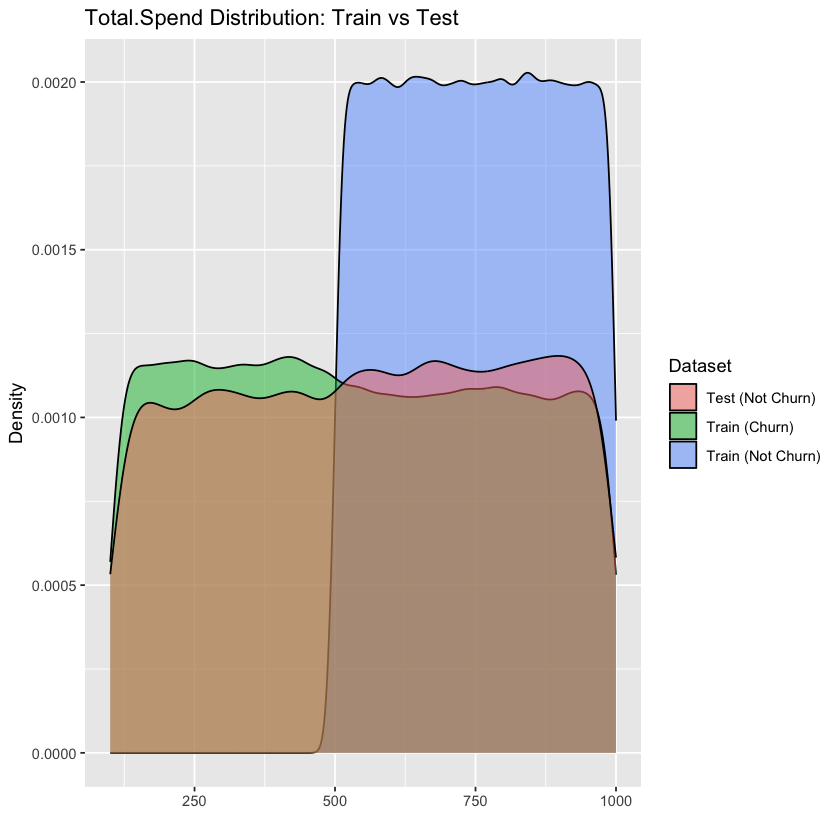

In [20]:
ggplot() +
    geom_density(data = df.train[df.train$Churn == 0, ], 
                 aes(x = Total.Spend, fill = "Train (Not Churn)"), alpha = 0.5) +
    geom_density(data = df.train[df.train$Churn == 1, ], 
                 aes(x = Total.Spend, fill = "Train (Churn)"), alpha = 0.5) +
    geom_density(data = df.test[df.test$Churn == 0, ], 
                 aes(x = Total.Spend, fill = "Test (Not Churn)"), alpha = 0.5) +
    labs(title = "Total.Spend Distribution: Train vs Test",
         x = "", y = "Density", fill = "Dataset")

In [21]:
df.all <- rbind(df.train[, names(df.test)], df.test)

set.seed(42)
train_idx <- sample(nrow(df.all), 0.8 * nrow(df.all))
df.train.new <- df.all[train_idx, ]
df.test.new  <- df.all[-train_idx, ]

df.train.new$Gender <- as.factor(df.train.new$Gender)
df.train.new$Subscription.Type <- as.factor(df.train.new$Subscription.Type)
df.train.new$Contract.Length <- as.factor(df.train.new$Contract.Length)
df.train.new$Churn <- as.factor(df.train.new$Churn)
df.train.new$Churn.num <- as.numeric(as.character(df.train.new$Churn))

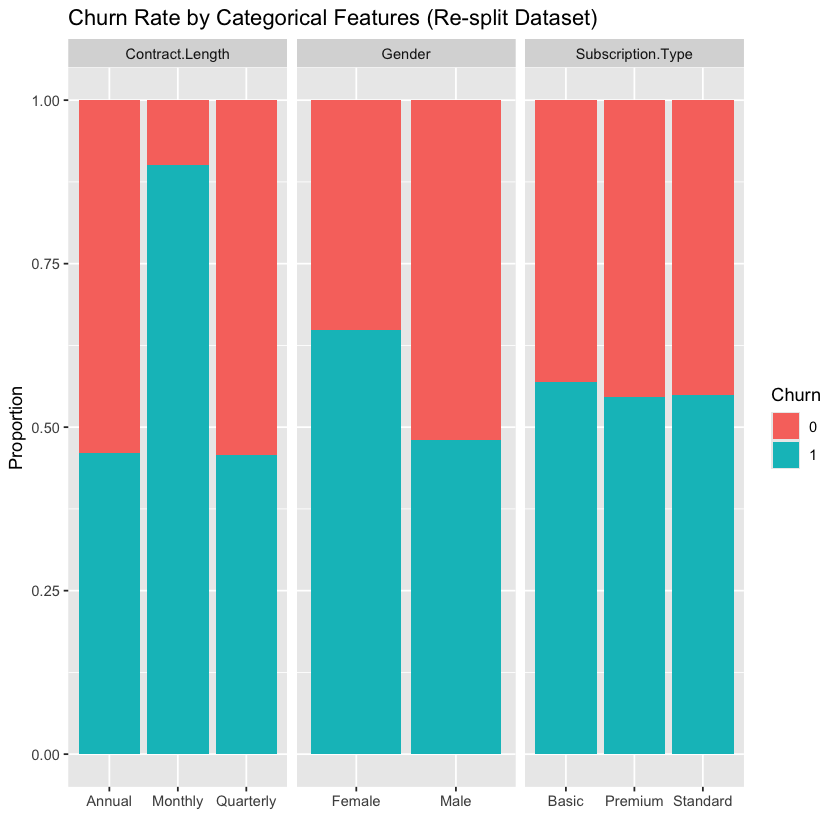

In [22]:
categorical.features <- c("Gender", "Subscription.Type", "Contract.Length")

df.cat.long <- pivot_longer(data = df.train.new[, c("Churn", categorical.features)],
                            cols = -Churn,
                            names_to = "feature",
                            values_to = "value")

ggplot(df.cat.long, aes(x = value, fill = Churn)) + 
    geom_bar(position = "fill") +
    facet_wrap(~ feature, scales = "free_x") +
    labs(title = "Churn Rate by Categorical Features (Re-split Dataset)",
         x = "", y = "Proportion")

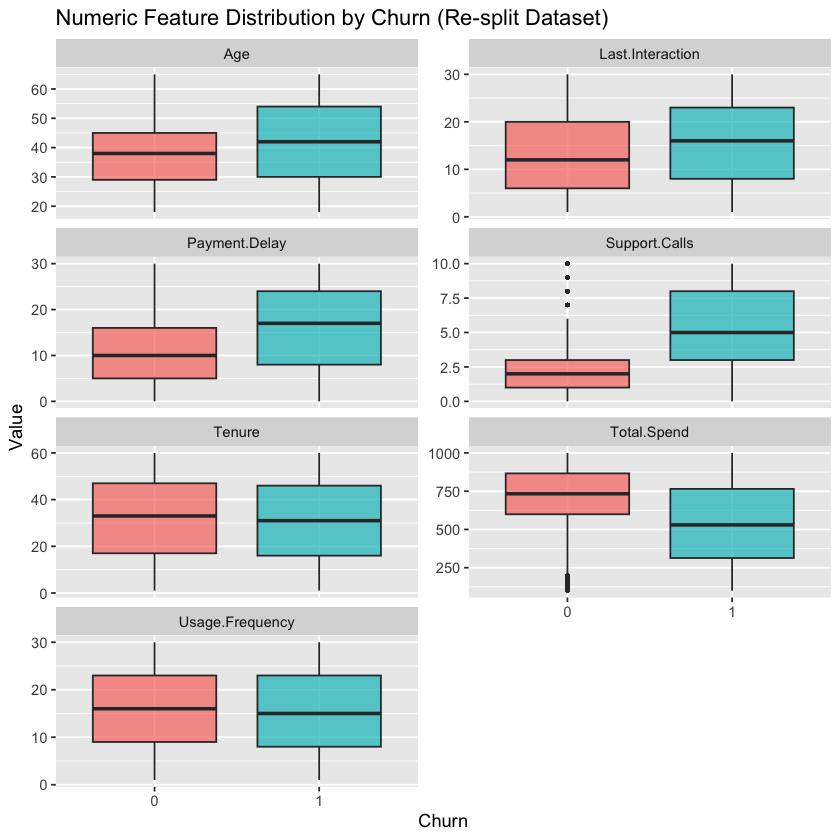

In [23]:
numeric.features <- c("Age", "Tenure", "Usage.Frequency", "Support.Calls", 
                  "Payment.Delay", "Total.Spend", "Last.Interaction")

df.long <- pivot_longer(data = df.train.new[, c("Churn", numeric.features)],
                        cols = -Churn,
                        names_to = "feature",
                        values_to = "value")

ggplot(df.long, aes(x = Churn, y = value, fill = Churn)) +
    geom_boxplot(outlier.size = 0.5, alpha = 0.7) + 
    facet_wrap(~ feature, scales = "free_y", ncol = 2) + 
    labs(title = "Numeric Feature Distribution by Churn (Re-split Dataset)", 
         x = "Churn", y = "Value") + 
    theme(legend.position = "none")

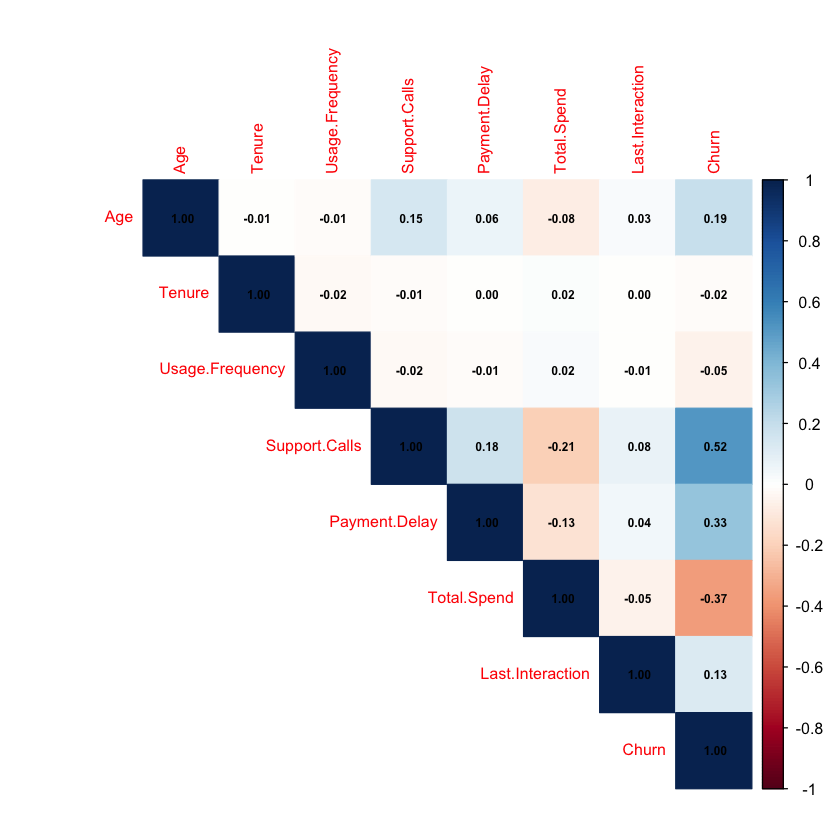

In [24]:
cor.data <- df.train.new[, numeric.features]
cor.data$Churn <- df.train.new$Churn.num

corrplot(cor(cor.data, use = "complete.obs"),
    method = "color",
    type = "upper",
    tl.cex = 0.8, 
    addCoef.col = "black",
    number.cex = 0.6)

In [25]:
lm.proxy.new <- lm(Churn.num ~ . - Churn, data = df.train.new)
vif.result <- vif(lm.proxy.new)

vif.data <- data.frame(
    Feature = rownames(vif.result),
    VIF = round(vif.result[, 1], 3)
)

print(vif.data, row.names = FALSE)

           Feature   VIF
               Age 1.028
            Gender 1.031
            Tenure 1.002
   Usage.Frequency 1.002
     Support.Calls 1.124
     Payment.Delay 1.051
 Subscription.Type 1.001
   Contract.Length 1.070
       Total.Spend 1.071
  Last.Interaction 1.026


In [26]:
step.result <- stats::step(lm.proxy.new, direction = "backward")
summary(step.result)

Start:  AIC=-813005.6
Churn.num ~ (Age + Gender + Tenure + Usage.Frequency + Support.Calls + 
    Payment.Delay + Subscription.Type + Contract.Length + Total.Spend + 
    Last.Interaction + Churn) - Churn

                    Df Sum of Sq   RSS     AIC
<none>                           54065 -813006
- Tenure             1       4.3 54069 -812975
- Subscription.Type  2      10.4 54075 -812932
- Usage.Frequency    1      95.5 54160 -812295
- Last.Interaction   1     586.0 54651 -808651
- Age                1     704.0 54769 -807779
- Gender             1     992.3 55057 -805657
- Payment.Delay      1    3667.8 57733 -786479
- Contract.Length    2    4341.9 58407 -781789
- Total.Spend        1    4454.3 58519 -781010
- Support.Calls      1   11819.2 65884 -733099



Call:
lm(formula = Churn.num ~ (Age + Gender + Tenure + Usage.Frequency + 
    Support.Calls + Payment.Delay + Subscription.Type + Contract.Length + 
    Total.Spend + Last.Interaction + Churn) - Churn, data = df.train.new)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.55414 -0.25669 -0.04312  0.28159  1.08667 

Coefficients:
                            Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                2.956e-01  3.500e-03   84.463  < 2e-16 ***
Age                        3.339e-03  4.603e-05   72.544  < 2e-16 ***
GenderMale                -1.012e-01  1.175e-03  -86.128  < 2e-16 ***
Tenure                    -1.897e-04  3.340e-05   -5.681 1.34e-08 ***
Usage.Frequency           -1.785e-03  6.683e-05  -26.714  < 2e-16 ***
Support.Calls              5.786e-02  1.946e-04  297.241  < 2e-16 ***
Payment.Delay              1.156e-02  6.981e-05  165.584  < 2e-16 ***
Subscription.TypePremium  -1.143e-02  1.414e-03   -8.085 6.26e-16 ***
Subscription.TypeStandard 

In [27]:
set.seed(42)
ctrl <- trainControl(method = "cv", number = 5)

cv.model.new <- train(Churn ~ Age + Gender + Tenure + Usage.Frequency + 
                        Support.Calls + Payment.Delay + Subscription.Type + 
                        Contract.Length + Total.Spend + Last.Interaction,
                      data = df.train.new,
                      method = "glm",
                      family = "binomial",
                      trControl = ctrl)

cv.model.new

Generalized Linear Model 

404164 samples
    10 predictor
     2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 323331, 323332, 323331, 323331, 323331 
Resampling results:

  Accuracy   Kappa    
  0.8486209  0.6946323


In [28]:
pred.new <- predict(cv.model.new, newdata = df.test.new, type = "raw")
cm.new <- confusionMatrix(pred.new, df.test.new$Churn)
cm.new

Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 37954  8557
         1  6854 47677
                                          
               Accuracy : 0.8475          
                 95% CI : (0.8452, 0.8497)
    No Information Rate : 0.5565          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.6922          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.8470          
            Specificity : 0.8478          
         Pos Pred Value : 0.8160          
         Neg Pred Value : 0.8743          
             Prevalence : 0.4435          
         Detection Rate : 0.3756          
   Detection Prevalence : 0.4603          
      Balanced Accuracy : 0.8474          
                                          
       'Positive' Class : 0               
                  

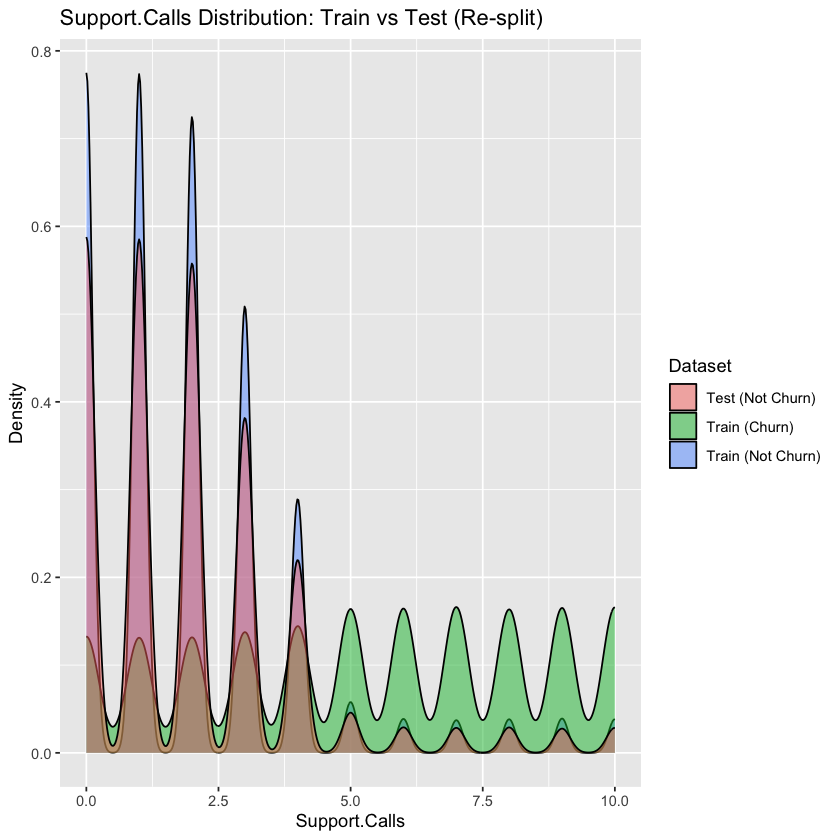

In [29]:
ggplot() +
    geom_density(data = df.train.new[df.train.new$Churn == 0, ], 
                 aes(x = Support.Calls, fill = "Train (Not Churn)"), alpha = 0.5) +
    geom_density(data = df.train.new[df.train.new$Churn == 1, ], 
                 aes(x = Support.Calls, fill = "Train (Churn)"), alpha = 0.5) +
    geom_density(data = df.test.new[df.test.new$Churn == 0, ], 
                 aes(x = Support.Calls, fill = "Test (Not Churn)"), alpha = 0.5) +
    labs(title = "Support.Calls Distribution: Train vs Test (Re-split)",
         x = "Support.Calls", y = "Density", fill = "Dataset")

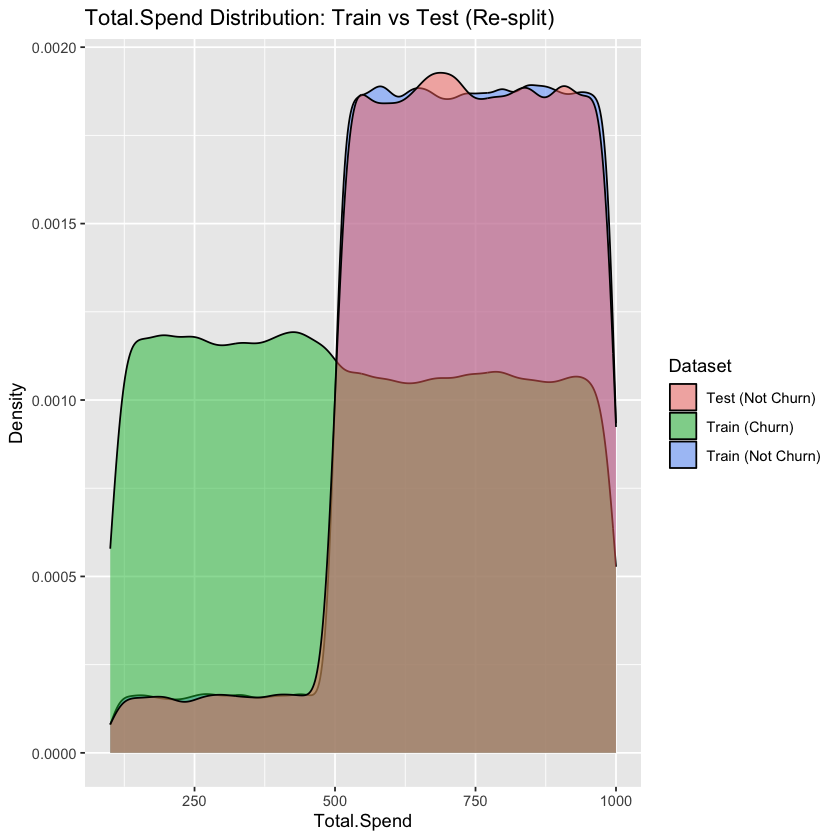

In [30]:
ggplot() +
    geom_density(data = df.train.new[df.train.new$Churn == 0, ], 
                 aes(x = Total.Spend, fill = "Train (Not Churn)"), alpha = 0.5) +
    geom_density(data = df.train.new[df.train.new$Churn == 1, ], 
                 aes(x = Total.Spend, fill = "Train (Churn)"), alpha = 0.5) +
    geom_density(data = df.test.new[df.test.new$Churn == 0, ], 
                 aes(x = Total.Spend, fill = "Test (Not Churn)"), alpha = 0.5) +
    labs(title = "Total.Spend Distribution: Train vs Test (Re-split)",
         x = "Total.Spend", y = "Density", fill = "Dataset")